<a href="https://colab.research.google.com/github/Ab-tldr/Movie-review-Sentiment-Analysis/blob/main/lstm_arima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/air_quality/"

In [ ]:
df = pd.read_csv(DATA_PATH + "dataset/city_day.csv", low_memory=False)


In [ ]:
stations = pd.read_csv(DATA_PATH +'dataset/stations.csv')

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values(['City', 'Date'], inplace=True)

###AQI CALCULATION

In [ ]:
import pandas as pd
import numpy as np

def get_subindex(pollutant, value):
    if pd.isna(value) or value <= 0: return 0
    bp = {
        'PM2.5': [(0,30,0,50), (30,60,50,100), (60,90,100,200), (90,120,200,300), (120,250,300,400), (250,1000,400,500)],
        'PM10': [(0,50,0,50), (50,100,50,100), (100,250,100,200), (250,350,200,300), (350,430,300,400), (430,1000,400,500)],
        'NO2': [(0,40,0,50), (40,80,50,100), (80,180,100,200), (180,280,200,300), (280,400,300,400), (400,1000,400,500)],
        'SO2': [(0,40,0,50), (40,80,50,100), (80,380,100,200), (380,800,200,300), (800,1600,300,400), (1600,2000,400,500)],
        'CO': [(0,1,0,50), (1,2,50,100), (2,10,100,200), (10,17,200,300), (17,34,300,400), (34,100,400,500)],
        'NH3': [(0,200,0,50), (200,400,50,100), (400,800,100,200), (800,1200,200,300), (1200,1800,300,400), (1800,3000,400,500)]
    }
    if pollutant not in bp: return 0
    for (cl, ch, il, ih) in bp[pollutant]:
        if cl <= value <= ch:
            return il + (value - cl) * (ih - il) / (ch - cl)
    return 500



In [ ]:
for p in ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'NH3']:
    df[f'{p}_si'] = df[p].apply(lambda x: get_subindex(p, x))

df['New_AQI'] = df[[f'{p}_si' for p in ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'NH3']]].max(axis=1)

In [ ]:
city_data = df[df['City'] == 'Delhi'].copy()
city_data['Date'] = pd.to_datetime(city_data['Date'])
city_data = city_data.sort_values('Date').set_index('Date')

numeric_cols = ['New_AQI', 'PM2.5', 'PM10', 'NO2']

aqi_series = city_data[['New_AQI']].resample('D').mean().interpolate()
aqi_series['New_AQI'] = aqi_series['New_AQI'].rolling(window=3).mean()
aqi_series = aqi_series.dropna()



In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled = scaler.fit_transform(aqi_series)



In [ ]:
def create_windows(data, lookback=30):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)



In [ ]:
X, y = create_windows(scaled)
split = int(0.8 * len(X))
X_train, X_test, y_train, y_test = X[:split], X[split:], y[:split], y[split:]

In [ ]:
from tensorflow.keras.regularizers import l2

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(30, 1), kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    LSTM(32, kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(1)
])
model.compile(optimizer='adam', loss='mae')



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)


history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)



Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 0.3398 - val_loss: 0.1591
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.1743 - val_loss: 0.1389
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.1533 - val_loss: 0.1256
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.1384 - val_loss: 0.1209
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.1282 - val_loss: 0.1139
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.1231 - val_loss: 0.1110
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.1251 - val_loss: 0.1064
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.1178 - val_loss: 0.1036
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.1137 - val_loss: 0.1070
Epoch 10/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.1150 - val_loss: 0.0992
Epoch 11/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.1068 - val_loss: 0.0979
Epoch 12/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step

In [ ]:
preds = model.predict(X_test)
inv_preds = scaler.inverse_transform(preds)
inv_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


Final RMSE: 17.86
Final MAE: 13.56


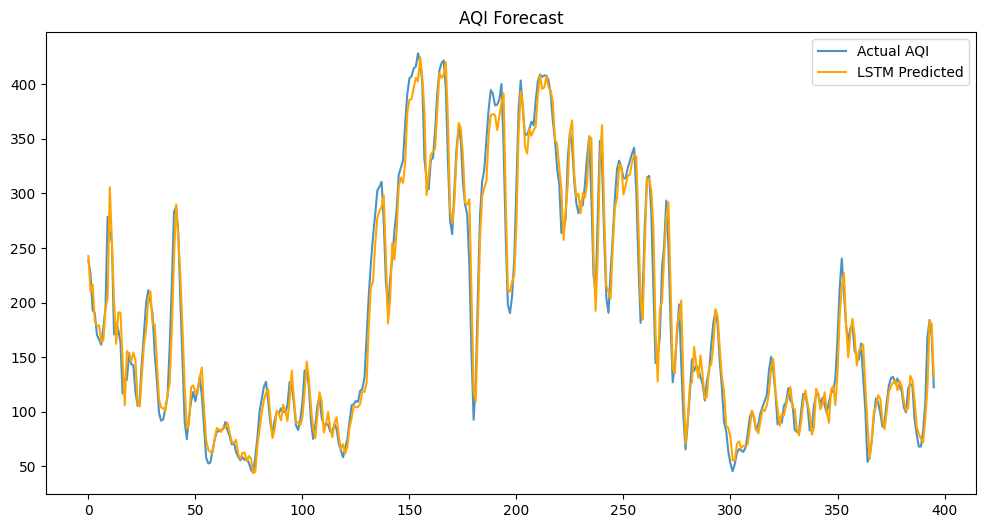

In [ ]:
print(f"Final RMSE: {np.sqrt(mean_squared_error(inv_actual, inv_preds)):.2f}")
print(f"Final MAE: {mean_absolute_error(inv_actual, inv_preds):.2f}")

plt.figure(figsize=(12, 6))
plt.plot(inv_actual, label='Actual AQI', alpha=0.8)
plt.plot(inv_preds, label='LSTM Predicted', color='orange')
plt.title('AQI Forecast')
plt.legend()
plt.show()

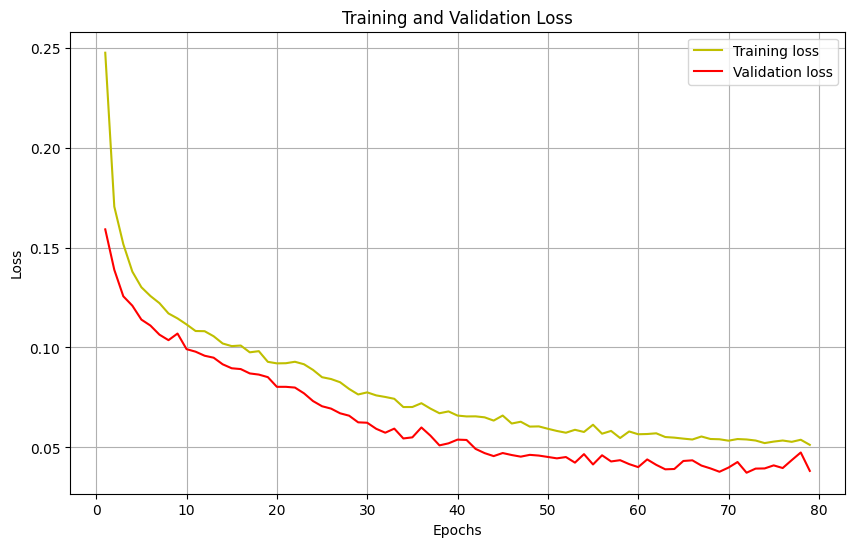

In [ ]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def get_aqi_bucket(x):
    if x <= 50: return "Good"
    elif x <= 100: return "Satisfactory"
    elif x <= 200: return "Moderate"
    elif x <= 300: return "Poor"
    elif x <= 400: return "Very Poor"
    else: return "Severe"



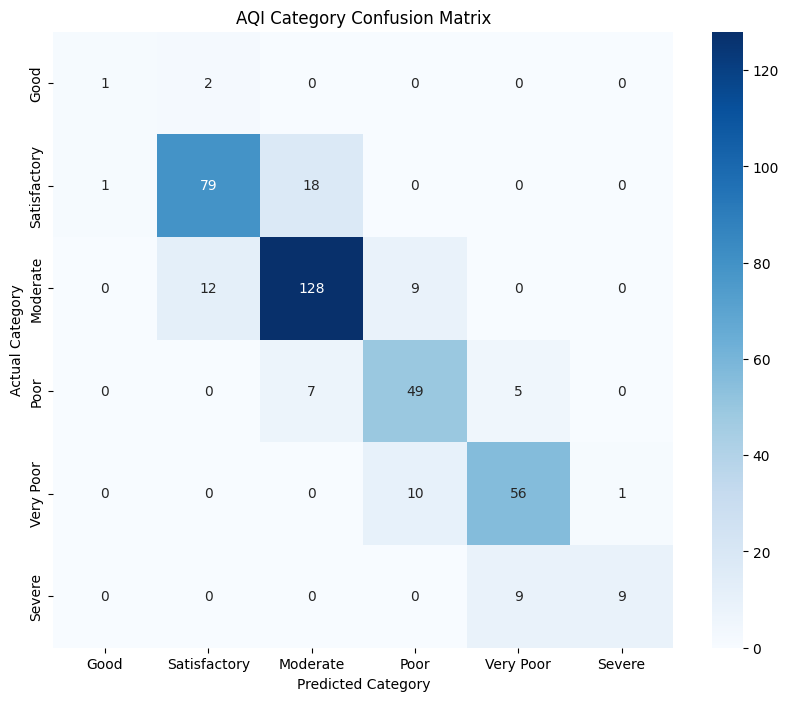

              precision    recall  f1-score   support

        Good       0.50      0.33      0.40         3
Satisfactory       0.85      0.81      0.83        98
    Moderate       0.84      0.86      0.85       149
        Poor       0.72      0.80      0.76        61
   Very Poor       0.80      0.84      0.82        67
      Severe       0.90      0.50      0.64        18

    accuracy                           0.81       396
   macro avg       0.77      0.69      0.72       396
weighted avg       0.82      0.81      0.81       396



In [ ]:
actual_buckets = [get_aqi_bucket(val) for val in inv_actual]
pred_buckets = [get_aqi_bucket(val) for val in inv_preds]

labels = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]

cm = confusion_matrix(actual_buckets, pred_buckets, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.title('AQI Category Confusion Matrix')
plt.show()

print(classification_report(actual_buckets, pred_buckets, labels=labels))

In [ ]:
model.save(DATA_PATH+'final_aqi_lstm.h5')

ARIMA

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

series = aqi_series['New_AQI']

def check_stationarity(data):
    result = adfuller(data)
    print(f'ADF Statistic: {result[0]:.3f}')
    print(f'p-value: {result[1]:.3f}')
    if result[1] <= 0.05:
        print("Data is stationary")
    else:
        print("Data is non-stationary, differencing required")

check_stationarity(series)

ADF Statistic: -3.605
p-value: 0.006
Data is stationary


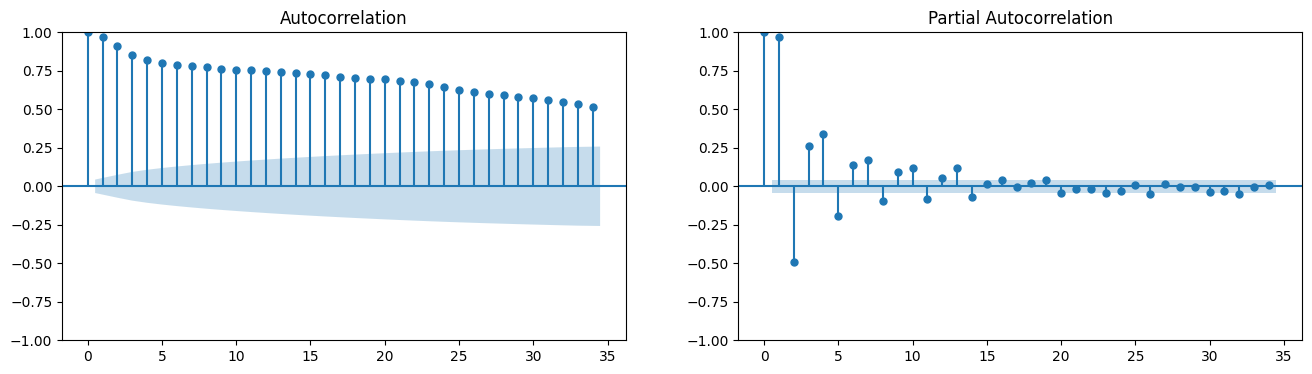

In [ ]:
diff_series = series.diff().dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(series, ax=ax1)
plot_pacf(series, ax=ax2)
plt.show()

In [ ]:
X = series.values
size = int(len(X) * 0.8)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
predictions = []



In [ ]:
print('Starting ARIMA Walk-Forward Validation...')
for t in range(len(test)):

    model = ARIMA(history, order=(2, 0, 2))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = test[t]
    history.append(obs)



Starting ARIMA Walk-Forward Validation...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Test RMSE: 16.767
Test MAE: 12.171


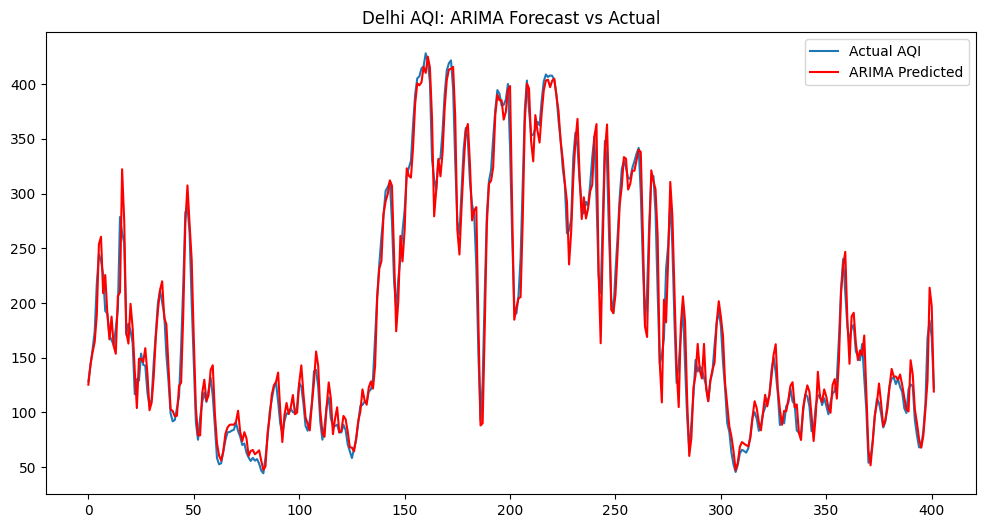

In [ ]:
rmse = np.sqrt(mean_squared_error(test, predictions))
print(f'Test RMSE: {rmse:.3f}')
print(f"Test MAE: {mean_absolute_error(test, predictions):.3f}")


plt.figure(figsize=(12, 6))
plt.plot(test, label='Actual AQI')
plt.plot(predictions, color='red', label='ARIMA Predicted')
plt.title('Delhi AQI: ARIMA Forecast vs Actual')
plt.legend()
plt.show()

In [ ]:
actual_buckets = [get_aqi_bucket(val) for val in test]
pred_buckets = [get_aqi_bucket(val) for val in predictions]

In [ ]:
cm_arima = confusion_matrix(actual_buckets, pred_buckets, labels=labels)

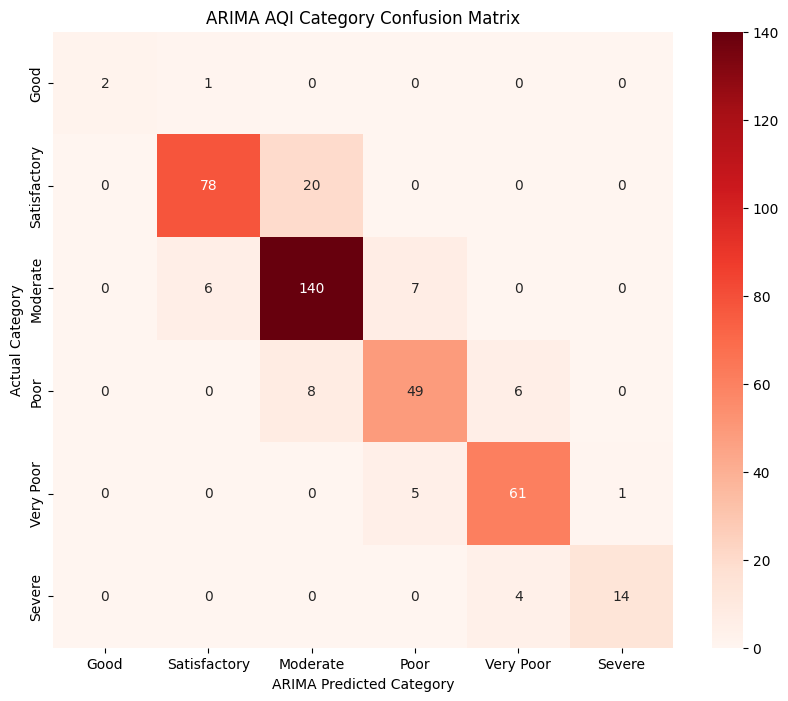

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm_arima, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Reds')
plt.xlabel('ARIMA Predicted Category')
plt.ylabel('Actual Category')
plt.title('ARIMA AQI Category Confusion Matrix')
plt.show()

In [ ]:
print("ARIMA CLASSIFICATION REPORT:")
print(classification_report(actual_buckets, pred_buckets, labels=labels))

ARIMA CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Good       1.00      0.67      0.80         3
Satisfactory       0.92      0.80      0.85        98
    Moderate       0.83      0.92      0.87       153
        Poor       0.80      0.78      0.79        63
   Very Poor       0.86      0.91      0.88        67
      Severe       0.93      0.78      0.85        18

    accuracy                           0.86       402
   macro avg       0.89      0.81      0.84       402
weighted avg       0.86      0.86      0.85       402



In [ ]:
model_fit.save(DATA_PATH + 'final_aqi_arima.pkl')

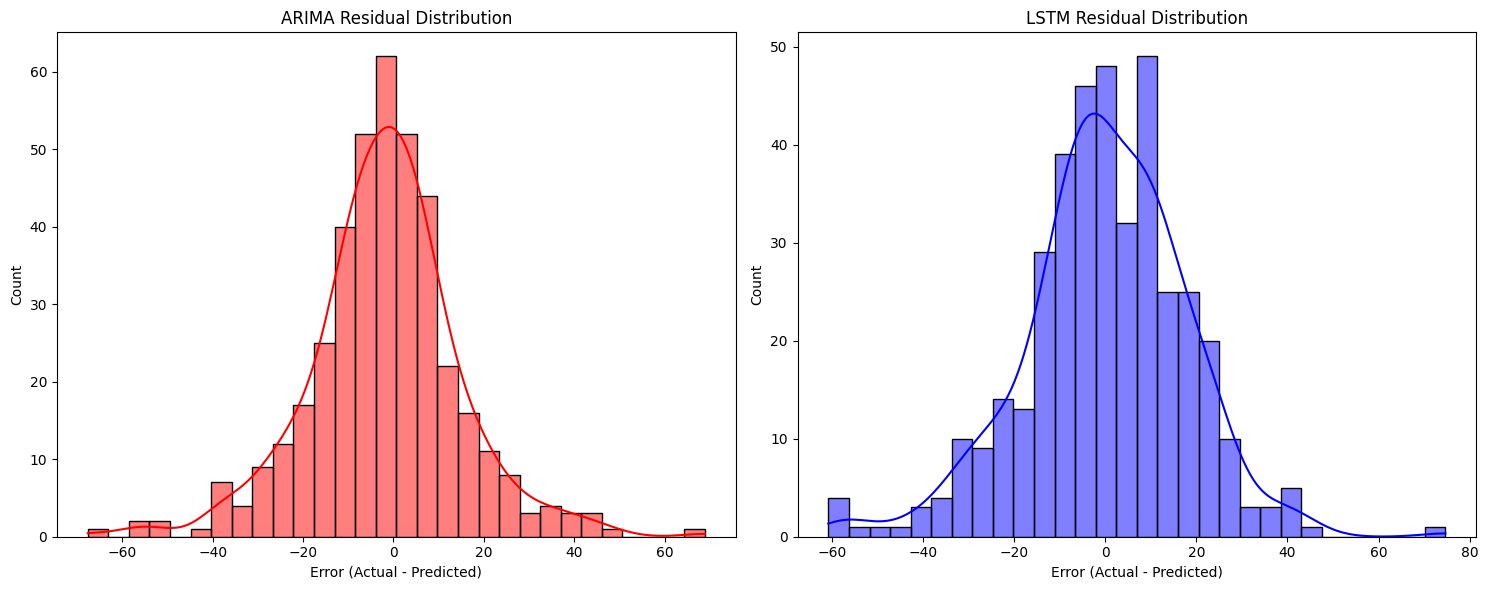

ARIMA Mean Residual: -1.98
LSTM Mean Residual: 0.00


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

arima_residuals = np.array(test) - np.array(predictions)
lstm_residuals = inv_actual.flatten() - inv_preds.flatten()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(arima_residuals, kde=True, ax=axes[0], color='red', bins=30)
axes[0].set_title('ARIMA Residual Distribution')
axes[0].set_xlabel('Error (Actual - Predicted)')

sns.histplot(lstm_residuals, kde=True, ax=axes[1], color='blue', bins=30)
axes[1].set_title('LSTM Residual Distribution')
axes[1].set_xlabel('Error (Actual - Predicted)')

plt.tight_layout()
plt.show()

print(f"ARIMA Mean Residual: {np.mean(arima_residuals):.2f}")
print(f"LSTM Mean Residual: {np.mean(lstm_residuals):.2f}")

In [ ]:
print(f"ARIMA Mean Residual: {np.mean(arima_residuals):.2f}")
print(f"LSTM Mean Residual: {np.mean(lstm_residuals):.2f}")

ARIMA Mean Residual: -1.98
LSTM Mean Residual: 0.00
